In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

from scipy.special import iv

import pickle

import schwingerModel as sim

In [2]:
m = .2
a = 1
dimx = 16
dimt = 32
beta = 10
totalSteps = 50000

In [ ]:
temp = sim.schwingerModel(metroSteps=totalSteps,beta=beta,dimx=dimx,dimt=dimt,aSpacing=a,fMass=m,cgRtol=1e-5)

100%|██████████| 50000/50000 [22:39:25<00:00,  1.63s/it]   


In [ ]:
# with open('50kSteps.pkl', 'wb') as f:
#     pickle.dump(temp,f)

In [3]:
with open('50kSteps.pkl', 'rb') as f:
    temp = pickle.load(f)

In [35]:
rhoBar = sim.analysis.getEffMassRhoBar(temp)
sim.analysis.get_integrated_autocorr_time_statistical(rhoBar,temp.metroSteps)

(np.float64(0.5998356123673423), np.float64(0.14692911798498715), 1)

In [9]:
gamma = np.array([[1,0],[0,1]])
bIn = 500
skp = 5
correl = sim.analysis.correlStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,includeDisc=False)
effectiveMass = sim.analysis.effectiveMassStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,includeDisc=False,coshExpr=False,cleanNans=False)

100%|██████████| 9900/9900 [08:16<00:00, 19.95it/s]
/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/analysis.py:102: RuntimeWarning: invalid value encountered in log
  effectiveMass = np.log(totalCorrels[:,:-1]/totalCorrels[:,1:])
/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/scipy/_lib/_util.py:365: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


In [10]:
effMass = np.log(np.abs(correl[0][:-1]/correl[0][1:]))
fracErrors = (((np.diff(correl[1])/2).T)/correl[0]).flatten()
effMassErr = np.sqrt(fracErrors[:-1]**2+fracErrors[1:]**2)

Text(0.5, 1.0, 'Correlation:  $N_t = 32$,$N_x=16$ $a=1$, $m=0.2$, $\\beta=10$, $\\Gamma=\\sigma_3$')

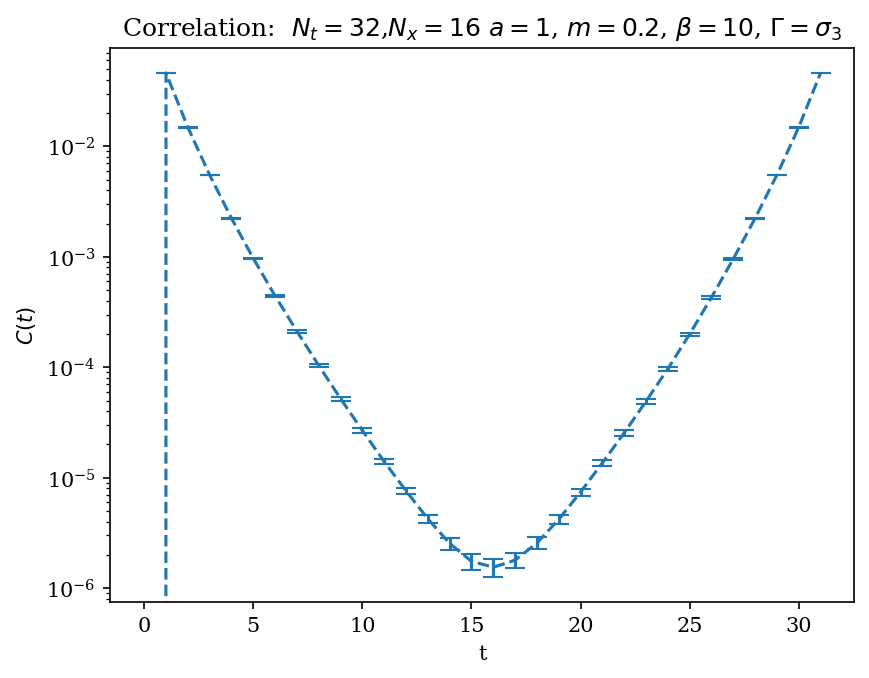

In [11]:
plt.figure(dpi=150)
plt.errorbar(x=np.arange(len(correl[0])),y=correl[0],yerr=correl[1].T,ls="--",capsize=5)
plt.semilogy()
plt.xlabel("t")
plt.ylabel(r"$C(t)$")
plt.title(rf"Correlation:  $N_t = {dimt}$,$N_x={dimx}$ $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_3$")

Text(0.5, 1.0, 'Effective Mass: $N_t = 32$,$N_x=16$ $a=1$, $m=0.2$, $\\beta=10$, $\\Gamma=\\sigma_3$')

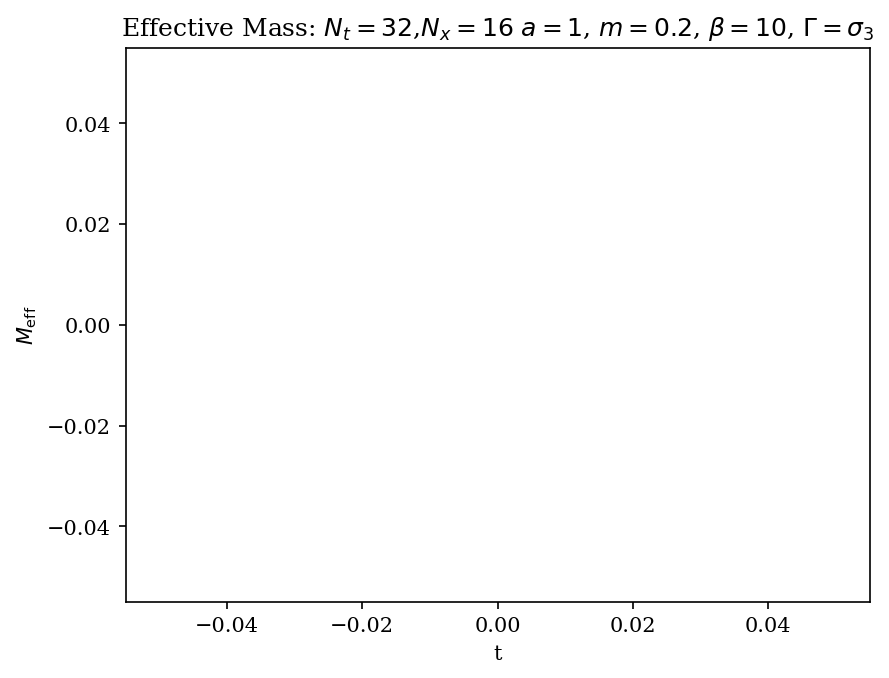

In [12]:
plt.figure(dpi=150)
plt.errorbar(x=np.arange(len(effectiveMass[0])),y=np.abs(effectiveMass[0]),yerr=effectiveMass[1].T,ls="--",capsize=5)
plt.xlabel("t")
plt.ylabel(r"$M_{\text{eff}}$")
plt.title(rf"Effective Mass: $N_t = {dimt}$,$N_x={dimx}$ $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_3$")

Text(0.5, 1.0, 'Effective Mass: $N_t = 32$,$N_x=16$ $a=1$, $m=0.2$, $\\beta=10$, $\\Gamma=\\sigma_3$')

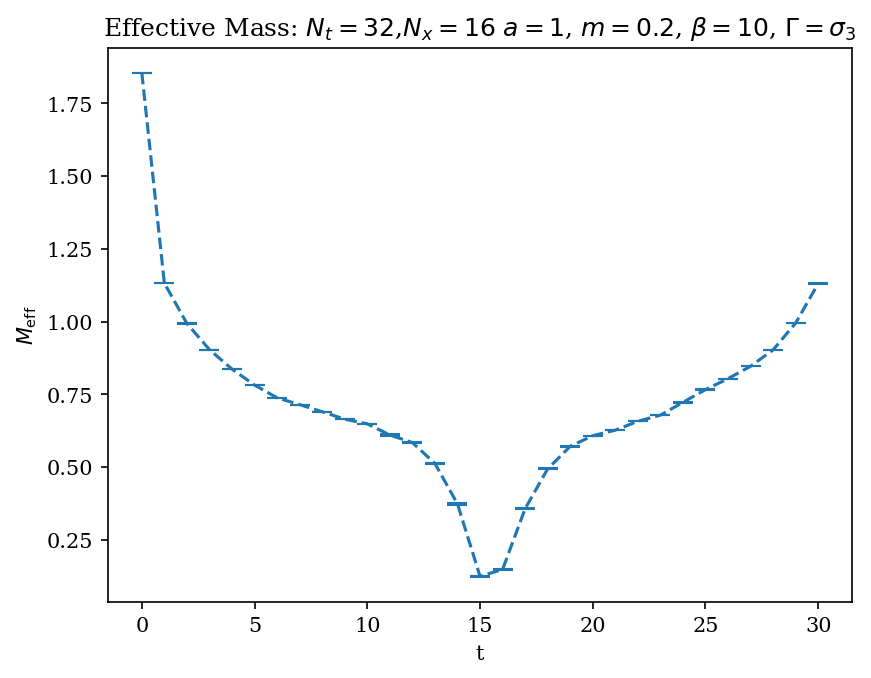

In [13]:
plt.figure(dpi=150)
plt.errorbar(x=np.arange(len(effMass)),y=np.abs(effMass),yerr=effMassErr,ls="--",capsize=5)
plt.xlabel("t")
plt.ylabel(r"$M_{\text{eff}}$")
plt.title(rf"Effective Mass: $N_t = {dimt}$,$N_x={dimx}$ $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_3$")

In [39]:
# testBetas = np.linspace(.5,5,8)

# models = Parallel(n_jobs=14)(delayed(schwingerModel)(metroSteps=1000,beta=b,dimx=8,dimt=8,aSpacing=1,fMass=.1) for b in testBetas)

# spStats = np.array([m.plaqStats(100) for m in models])

In [40]:
# plt.figure(dpi=250)
# plt.errorbar(testBetas,spStats[:,0],yerr=spStats[:,1],capsize=3,fmt=".")
# plt.xlabel(r"$\beta$")
# plt.ylabel(r"$\langle \cos \theta_P \rangle$")

# plt.plot(testBetas,iv(1,testBetas)/iv(0,testBetas),label=r"Exact (no $\psi$): $\frac{I_1(\beta)}{I_0(\beta)}$")
# plt.legend()